In [80]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pylab as pl
import scipy as sp
from scipy import signal
from statsmodels.tsa.stattools import acf
from functools import partial
import math
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera

## Data preparation

## TODO: stationary test/more detailed tests on the time series properties (like fat tails, etc.)

In [81]:
sns.set_theme(style="whitegrid")

tickers = ["GC=F", "PAXG-USD", "DX-Y.NYB"]
start_date = "2020-03-20"
end_date = "2026-03-20"

raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']


[*********************100%***********************]  3 of 3 completed


In [82]:
# Clean and Align the Data (The "Inner Join" logic)
# Traditional markets are closed on weekends/holidays, resulting in NaNs.
# Using .dropna() automatically drops the crypto weekend data, aligning everything perfectly.
aligned_data = raw_data.dropna()
aligned_data.columns = ['US Dollar Index', 'Physical Gold', 'PAX Gold']

# Calculate Daily Log-Returns
# Formula: ln(P_t / P_{t-1})
# !!!! attention, we *100 to scale the data

log_returns = np.log(aligned_data / aligned_data.shift(1)).dropna()
gold_array = log_returns['Physical Gold'].values*100
paxg_array = log_returns['PAX Gold'].values*100
usd_array = log_returns['US Dollar Index'].values*100
print(f"Shape of the NumPy arrays: {gold_array.shape} days of trading.")


Shape of the NumPy arrays: (1507,) days of trading.


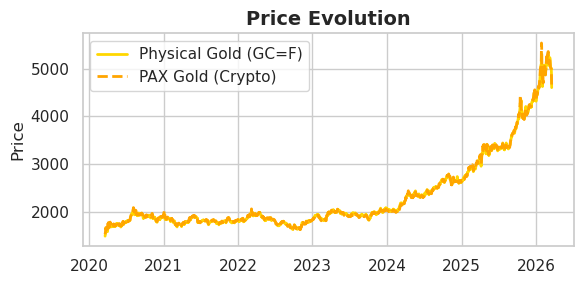

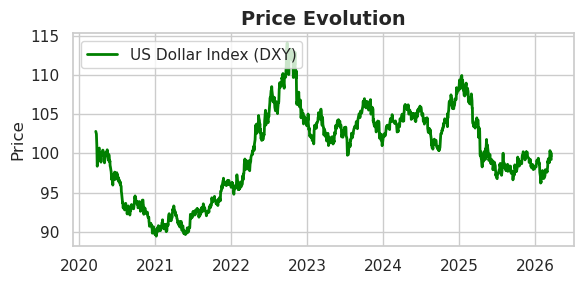

In [83]:
plt.figure(figsize=(6, 3))
plt.plot(aligned_data['Physical Gold'].index, aligned_data['Physical Gold'], label='Physical Gold (GC=F)', color='gold', linewidth=2)
plt.plot(aligned_data.index, aligned_data['PAX Gold'], label='PAX Gold (Crypto)', color='orange', linestyle='--', linewidth=2)
plt.title('Price Evolution', fontsize=14, fontweight='bold')
plt.ylabel('Price', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(aligned_data.index, aligned_data['US Dollar Index'], label='US Dollar Index (DXY)', color='green', linewidth=2)

plt.title('Price Evolution', fontsize=14, fontweight='bold')
plt.ylabel('Price', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

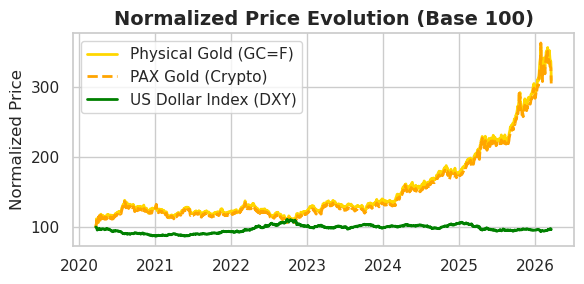

In [84]:
normalized_prices = (aligned_data / aligned_data.iloc[0]) * 100

plt.figure(figsize=(6, 3))
plt.plot(normalized_prices.index, normalized_prices['Physical Gold'], label='Physical Gold (GC=F)', color='gold', linewidth=2)
plt.plot(normalized_prices.index, normalized_prices['PAX Gold'], label='PAX Gold (Crypto)', color='orange', linestyle='--', linewidth=2)
plt.plot(normalized_prices.index, normalized_prices['US Dollar Index'], label='US Dollar Index (DXY)', color='green', linewidth=2)

plt.title('Normalized Price Evolution (Base 100)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Price', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [85]:
print("In terms of daily log-return, we cannot say that \nthe tendance of the price of gold or PAX Gold is increasing, as we see in the figures aboves.")
print(np.mean(log_returns['Physical Gold']), np.mean(log_returns['PAX Gold']), np.mean(log_returns['US Dollar Index']))
print("For usd, it may proper to manually fix the mean as zero in the GARCH model.")

In terms of daily log-return, we cannot say that 
the tendance of the price of gold or PAX Gold is increasing, as we see in the figures aboves.
0.0007508078059312598 0.0007407307891193007 -2.358292097101863e-05
For usd, it may proper to manually fix the mean as zero in the GARCH model.


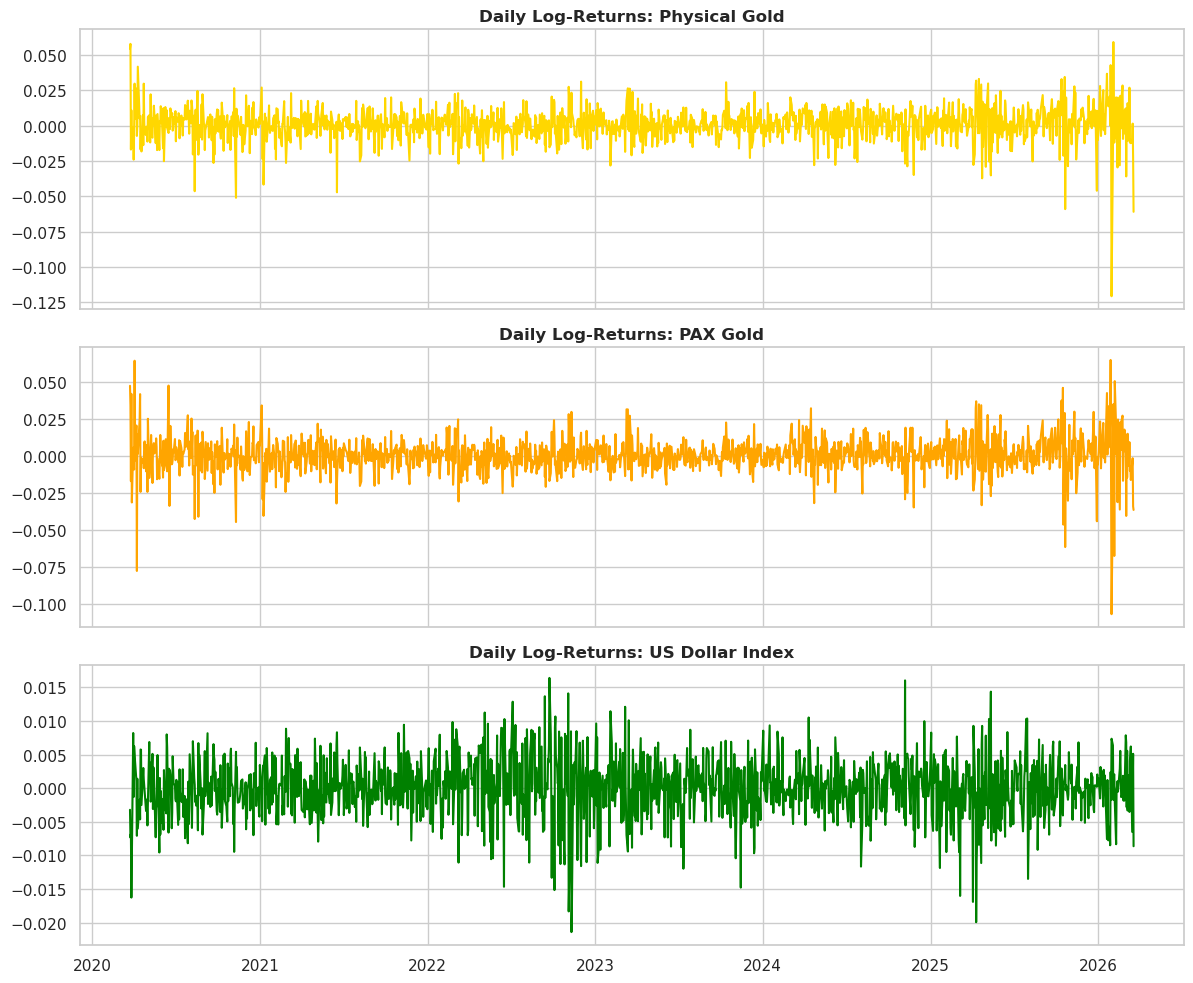

In [86]:
# log return
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(log_returns.index, log_returns['Physical Gold'], color='gold')
axes[0].set_title('Daily Log-Returns: Physical Gold', fontweight='bold')

axes[1].plot(log_returns.index, log_returns['PAX Gold'], color='orange')
axes[1].set_title('Daily Log-Returns: PAX Gold', fontweight='bold')

axes[2].plot(log_returns.index, log_returns['US Dollar Index'], color='green')
axes[2].set_title('Daily Log-Returns: US Dollar Index', fontweight='bold')

plt.tight_layout()
plt.show()

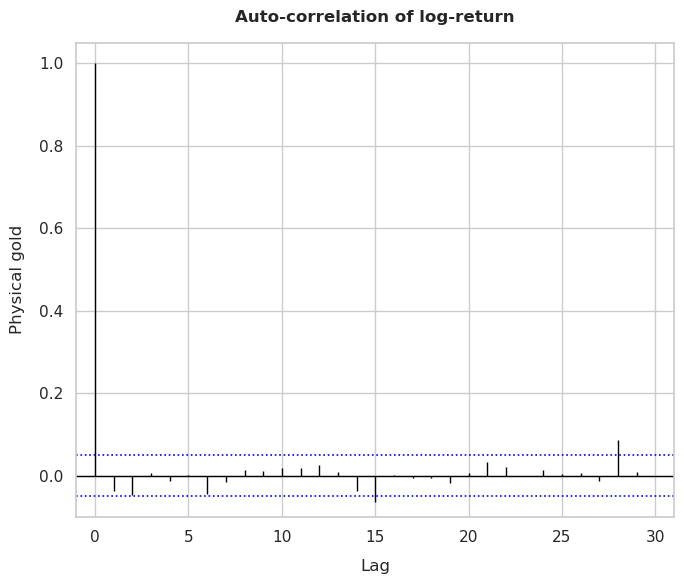

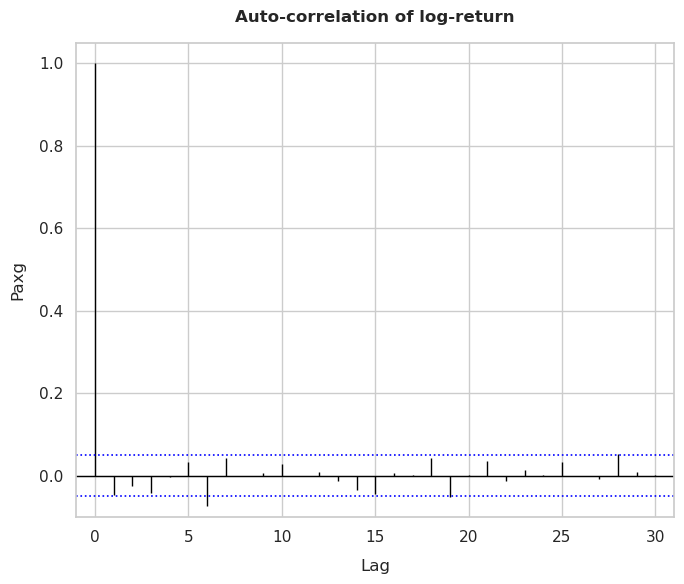

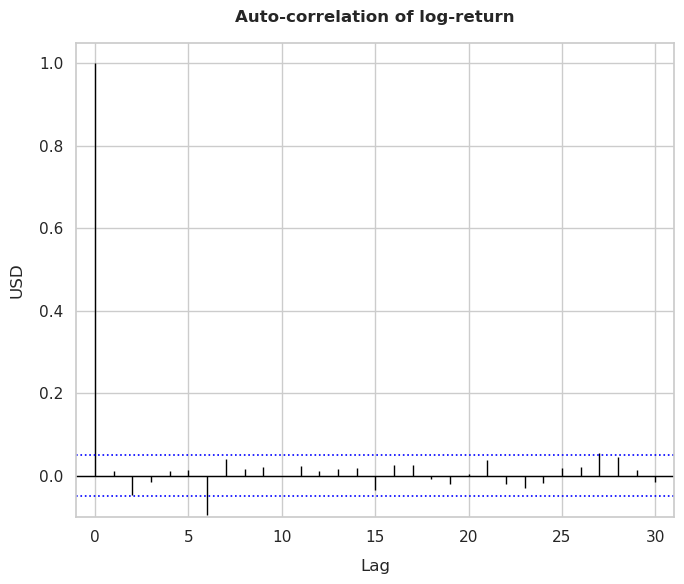

In [87]:
# Fonction d’autocovariance échantillonnale

nlags = 30

# gold 
gold_valeurs_acf = acf(gold_array, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(gold_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=gold_valeurs_acf, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of log-return", fontweight='bold', pad=15)
plt.ylabel("Physical gold", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()


# paxg 
paxg_valeurs_acf = acf(paxg_array, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(paxg_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=paxg_valeurs_acf, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)

plt.title("Auto-correlation of log-return", fontweight='bold', pad=15)
plt.ylabel("Paxg", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

# usd
usd_valeurs_acf = acf(usd_array, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(usd_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=usd_valeurs_acf, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of log-return", fontweight='bold', pad=15)
plt.ylabel("USD", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

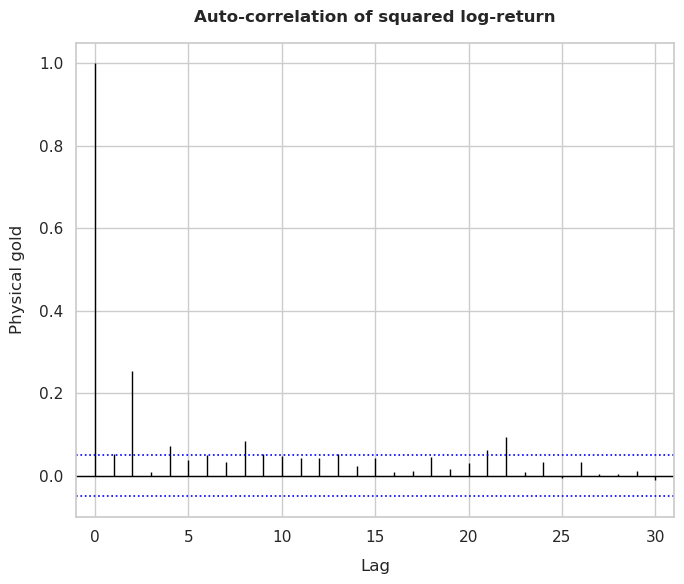

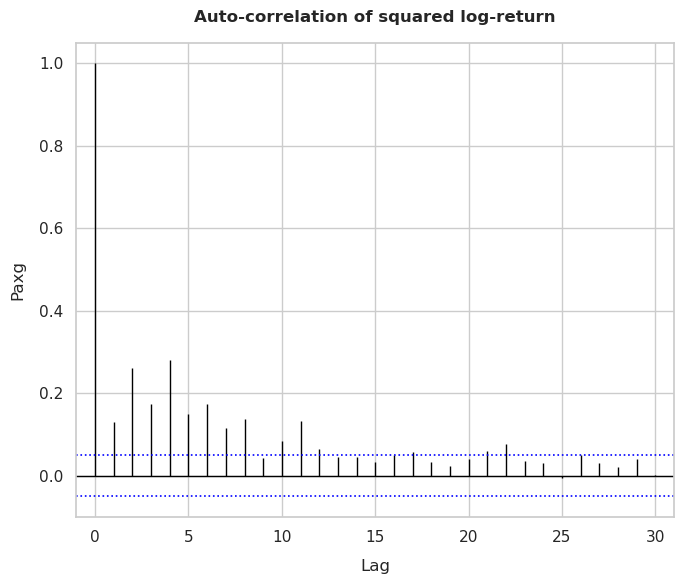

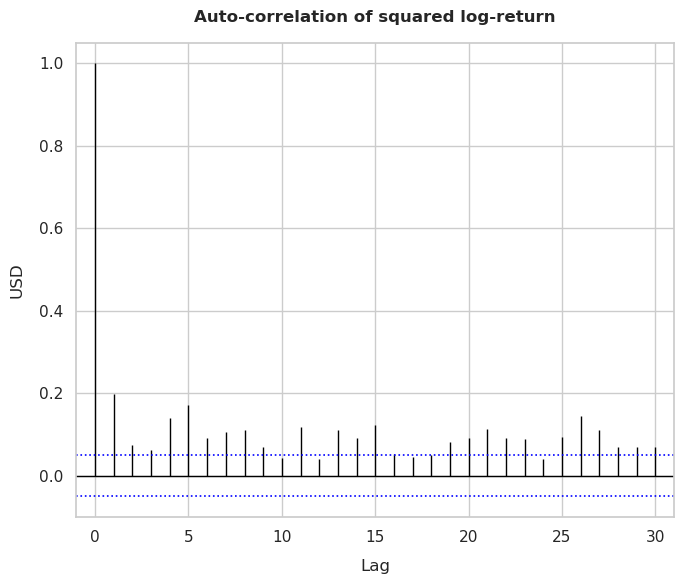

In [88]:
nlags = 30

# gold 
gold_valeurs_acf2 = acf(gold_array**2, nlags=nlags, fft=True)
lags = np.arange(nlags + 1)

N = len(gold_array)
intervalle_confiance = 1.96 / np.sqrt(N)

plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=gold_valeurs_acf2, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of squared log-return", fontweight='bold', pad=15)
plt.ylabel("Physical gold", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()


# paxg 
paxg_valeurs_acf2 = acf(paxg_array**2, nlags=nlags, fft=True)
plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=paxg_valeurs_acf2, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)

plt.title("Auto-correlation of squared log-return", fontweight='bold', pad=15)
plt.ylabel("Paxg", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

# usd
usd_valeurs_acf2 = acf(usd_array**2, nlags=nlags, fft=True)


plt.figure(figsize=(7, 6))

plt.vlines(x=lags, ymin=0, ymax=usd_valeurs_acf2, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)

plt.axhline(y=intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)
plt.axhline(y=-intervalle_confiance, color='blue', linestyle=':', linewidth=1.2)


plt.title("Auto-correlation of squared log-return", fontweight='bold', pad=15)
plt.ylabel("USD", labelpad=10) 
plt.xlabel("Lag", labelpad=10)


plt.ylim(min(-0.1, -intervalle_confiance - 0.05), 1.05)
plt.xlim(-1, nlags + 1)


ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

- log-return is in general close to a white noise, that is a stationary process at order 2.
- However, there is significant autocorrelation in the time series of squared log-return. This is not compatible with an iid white noise.
- We see volatility clustering in the data: Large values of squared log-return tend to be followed by high values of squared log-return. 
- This is not incompatible with stationary returns, and in particular with a constant variance of the returns.
- This is the reason why we cannot simply use ARMA process, which does not include volatility clustering. 

## GARCH  

### Use package arch for parameters estimation (MLE inside)

Look at https://arch.readthedocs.io/en/latest/univariate/introduction.html for parameter explanations.

In [89]:
from arch import arch_model

In [90]:

gold_garch_model = arch_model(gold_array, vol='GARCH', p=1, q=1, dist='Normal')

# Fit the model using Maximum Likelihood Estimation
# Python will use an optimizer (like 'SLSQP' or 'BFGS') to maximize the likelihood.
gold_garch_results = gold_garch_model.fit(update_freq=20, disp='on')

print(gold_garch_results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2230.45
Distribution:                  Normal   AIC:                           4468.91
Method:            Maximum Likelihood   BIC:                           4490.18
                                        No. Observations:                 1507
Date:                Tue, Mar 24 2026   Df Residuals:                     1506
Time:                        18:36:31   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0375  2.831e-02      1.325      0.185 

In [91]:
paxg_garch_model = arch_model(paxg_array, vol='GARCH',p=1, q=1, dist='Normal')

paxg_garch_results = paxg_garch_model.fit(update_freq=20, disp='on')

print(paxg_garch_results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2175.20
Distribution:                  Normal   AIC:                           4358.39
Method:            Maximum Likelihood   BIC:                           4379.66
                                        No. Observations:                 1507
Date:                Tue, Mar 24 2026   Df Residuals:                     1506
Time:                        18:36:31   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0467  2.426e-02      1.925  5.424e-02 

In [92]:
usd_garch_model = arch_model(usd_array, vol='GARCH',mean='Zero',p=1, q=1, dist='Normal')

usd_garch_results = usd_garch_model.fit(update_freq=20, disp='on')

print(usd_garch_results.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -831.366
Distribution:                  Normal   AIC:                           1668.73
Method:            Maximum Likelihood   BIC:                           1684.69
                                        No. Observations:                 1507
Date:                Tue, Mar 24 2026   Df Residuals:                     1507
Time:                        18:36:32   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      2.6301e-03  1.241e-03      2.119  3.408e-02 [1.

**Attention:** the estimated mu for gold and paxg has a confidence interval quite large, which includes 0... 
And we have forced mean = zero for usd.

## Alternative: use GMM to estimate parameters

Used moments
1. $\mathbb{E}[\hat\epsilon_t]$
2. $\mathbb{E}[\hat\epsilon_t^2 - 1]$
3. $\mathbb{E}[\text{skew} (\hat\epsilon_t)]$
4. $\mathbb{E}[\text{kurt} (\hat\epsilon_t) - 3]$

MMG steps:

1. Initialise $W = I$.
2. Estimate $\hat\theta$ by minimizing $\bar g(\theta)' W \bar g(\theta)$.
3. Recompute $W$ with empiric covariance of the moments and iterate.

In [93]:
garch_results = {
    "gold": gold_garch_results,
    "paxg": paxg_garch_results,
    "usd": usd_garch_results,
}

def compute_squared_sigmas(X, initial_sigma, theta):
    omega, alpha, beta = theta
    T = len(X)
    sigma2 = np.ndarray(T)
    sigma2[0] = initial_sigma ** 2
    for t in range(1, T):
        sigma2[t] = omega + alpha * X[t - 1] ** 2 + beta * sigma2[t - 1]
    return sigma2

def standardized_moment(x, mu, sigma, n):
    return ((x - mu) ** n) / (sigma ** n)

def gmm_objective(X, W, theta):
    initial_sigma = np.sqrt(np.mean(X ** 2))
    sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta))
    e = X / sigma

    m1 = np.mean(e)
    m2 = np.mean(e ** 2) - 1
    m3 = np.mean(standardized_moment(e, np.mean(e), np.std(e), 3))
    m4 = np.mean(standardized_moment(e, np.mean(e), np.std(e), 4) - 3)

    G = np.matrix([m1, m2, m3, m4]).T
    return (G.T * W * G).item()

def gmm_variance(X, theta):
    initial_sigma = np.sqrt(np.mean(X ** 2))
    sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta))
    e = X / sigma

    m1 = e ** 2
    m2 = (e ** 2 - 1) ** 2
    m3 = standardized_moment(e, np.mean(e), np.std(e), 3) ** 2
    m4 = (standardized_moment(e, np.mean(e), np.std(e), 4) - 3) ** 2

    T = len(X)
    s = np.zeros((4, 4))
    for t in range(T):
        G = np.matrix([m1[t], m2[t], m3[t], m4[t]]).T
        s = s + G * G.T

    return s / T

def constraint1(theta):
    return np.array([1 - (theta[1] + theta[2])])

def constraint2(theta):
    return np.array([theta[1]])

def constraint3(theta):
    return np.array([theta[2]])

def constraint4(theta):
    return np.array([theta[0]])

cons = (
    {"type": "ineq", "fun": constraint1},
    {"type": "ineq", "fun": constraint2},
    {"type": "ineq", "fun": constraint3},
    {"type": "ineq", "fun": constraint4},
)

def fit_iterated_gmm(X, theta0, gmm_iterations=10):
    W = np.identity(4)
    theta_est = np.asarray(theta0, dtype=float)
    for _ in range(gmm_iterations):
        objective = partial(gmm_objective, X, W)
        result = sp.optimize.minimize(
            objective,
            theta_est,
            method="SLSQP",
            constraints=cons,
        )
        theta_est = result.x
        W = np.linalg.pinv(gmm_variance(X, theta_est))
    return theta_est, result.fun

asset_data = {"gold": gold_array, "paxg": paxg_array, "usd": usd_array}
gmm_results = {}

for asset, mle_res in garch_results.items():
    X_asset = np.asarray(asset_data[asset], dtype=float)
    X_asset = (X_asset - np.mean(X_asset)) / np.std(X_asset)

    mle_params = mle_res.params
    theta0 = [
        float(mle_params["omega"]),
        float(mle_params["alpha[1]"]),
        float(mle_params["beta[1]"]),
    ]

    theta_gmm, objective_value = fit_iterated_gmm(X_asset, theta0, gmm_iterations=10)

    gmm_results[asset] = {
        "objective": float(objective_value),
        "params": {
            "mu": 0.0,
            "omega": float(theta_gmm[0]),
            "alpha[1]": float(theta_gmm[1]),
            "beta[1]": float(theta_gmm[2]),
        },
    }

pd.DataFrame({
    a: {
        "MMG_objective": gmm_results[a]["objective"],
        "omega": gmm_results[a]["params"]["omega"],
        "alpha[1]": gmm_results[a]["params"]["alpha[1]"],
        "beta[1]": gmm_results[a]["params"]["beta[1]"],
    }
    for a in gmm_results
}).T

/tmp/ipykernel_35205/1175325955.py:21: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta))


,MMG_objective,omega,alpha[1],beta[1]
gold,0.000004,0.232674,0.308908,0.514596
paxg,0.000023,0.076108,0.159128,0.755994
usd,0.000080,0.031322,0.042194,0.925057


In [94]:
coherence_rows = []

for asset, mle_res in garch_results.items():
    mle_p = mle_res.params.to_dict()
    gmm_p = gmm_results[asset]["params"]

    mle_persistence = float(mle_p["alpha[1]"]) + float(mle_p["beta[1]"])
    gmm_persistence = float(gmm_p["alpha[1]"]) + float(gmm_p["beta[1]"])

    coherence_rows.append(
        {
            "asset": asset,
            "MLE_persistence_alpha_plus_beta": mle_persistence,
            "MMG_persistence_alpha_plus_beta": gmm_persistence,
            "MLE_stationary": mle_persistence < 1,
            "MMG_stationary": gmm_persistence < 1,
            "stationarity_coherent": (mle_persistence < 1) == (gmm_persistence < 1),
        }
    )

coherence_df = pd.DataFrame(coherence_rows).sort_values("asset")
coherence_df

,asset,MLE_persistence_alpha_plus_beta,MMG_persistence_alpha_plus_beta,MLE_stationary,MMG_stationary,stationarity_coherent
0,gold,0.952564,0.823504,True,True,True
1,paxg,0.955246,0.915122,True,True,True
2,usd,0.985501,0.967251,True,True,True


In [95]:
coherence_with_obj = coherence_df.copy()
coherence_with_obj["MMG_objective"] = coherence_with_obj["asset"].map(
    lambda a: gmm_results[a]["objective"]
)
display(coherence_with_obj)

,asset,MLE_persistence_alpha_plus_beta,MMG_persistence_alpha_plus_beta,MLE_stationary,MMG_stationary,stationarity_coherent,MMG_objective
0,gold,0.952564,0.823504,True,True,True,0.000004
1,paxg,0.955246,0.915122,True,True,True,0.000023
2,usd,0.985501,0.967251,True,True,True,0.000080


## EVT on standardized GARCH residuals (POT-GPD)

Now that GARCH models are fitted, we model extreme tails of standardized residuals using EVT.

Workflow:
1. Compute standardized residuals $z_t$ from each fitted GARCH model.
2. Focus on left-tail risk via $Y_t=-z_t$.
3. Fit a GPD on exceedances above a high threshold $u$.
4. Combine EVT tail quantiles with 1-step-ahead GARCH forecasts to get conditional VaR and ES.

In [96]:
from scipy.stats import genpareto

# POT setup for left tail: work on Y=-z so extremes are large positive values
tail_quantile = 0.95
alpha_levels = [0.01, 0.025, 0.05]

evt_fits = {}

for asset, res in garch_results.items():
    z = pd.Series(res.std_resid).dropna().to_numpy()
    y = -z

    u = np.quantile(y, tail_quantile)
    exceedances = y[y > u] - u

    if len(exceedances) < 30:
        print(f"{asset}: warning - only {len(exceedances)} exceedances, estimates may be unstable")

    xi, loc, beta = genpareto.fit(exceedances, floc=0)
    p_u = len(exceedances) / len(y)

    evt_fits[asset] = {
        "threshold_u": u,
        "xi": xi,
        "beta": beta,
        "p_u": p_u,
        "n": len(y),
        "n_exc": len(exceedances),
    }

pd.DataFrame(evt_fits).T

,threshold_u,xi,beta,p_u,n,n_exc
gold,1.665124,0.188274,0.626505,0.050431,1507.0,76.0
paxg,1.546700,-0.071598,0.723636,0.050431,1507.0,76.0
usd,1.605972,-0.014000,0.555215,0.050431,1507.0,76.0


In [97]:
def evt_left_quantile_z(alpha, u, xi, beta, p_u):
    if alpha >= p_u:
        return np.nan
    if abs(xi) < 1e-8:
        y_alpha = u + beta * np.log(p_u / alpha)
    else:
        y_alpha = u + (beta / xi) * ((alpha / p_u) ** (-xi) - 1.0)
    return -y_alpha

def evt_left_es_z(alpha, u, xi, beta, p_u):
    qz = evt_left_quantile_z(alpha, u, xi, beta, p_u)
    if np.isnan(qz) or xi >= 1:
        return np.nan

    y_alpha = -qz
    e_y_given_tail = y_alpha + (beta + xi * (y_alpha - u)) / (1 - xi)
    return -e_y_given_tail

rows = []

for asset, res in garch_results.items():
    pars = evt_fits[asset]

    fc = res.forecast(horizon=1, reindex=False)
    mu_fc = float(fc.mean.iloc[-1, 0]) if fc.mean is not None else 0.0
    sigma_fc = float(np.sqrt(fc.variance.iloc[-1, 0]))

    for alpha in alpha_levels:
        qz = evt_left_quantile_z(alpha, pars["threshold_u"], pars["xi"], pars["beta"], pars["p_u"])
        esz = evt_left_es_z(alpha, pars["threshold_u"], pars["xi"], pars["beta"], pars["p_u"])

        var_ret = mu_fc + sigma_fc * qz if not np.isnan(qz) else np.nan
        es_ret = mu_fc + sigma_fc * esz if not np.isnan(esz) else np.nan

        rows.append(
            {
                "asset": asset,
                "alpha": alpha,
                "mu_forecast": mu_fc,
                "sigma_forecast": sigma_fc,
                "VaR_conditional": var_ret,
                "ES_conditional": es_ret,
            }
        )

risk_table = pd.DataFrame(rows).sort_values(["asset", "alpha"])
risk_table

,asset,alpha,mu_forecast,sigma_forecast,VaR_conditional,ES_conditional
0,gold,0.010,0.037509,2.281387,-6.464854,-8.852742
1,gold,0.025,0.037509,2.281387,-4.833551,-6.843071
2,gold,0.050,0.037509,2.281387,-3.773572,-5.537238
3,paxg,0.010,0.046699,2.028806,-5.334277,-6.554437
4,paxg,0.025,0.046699,2.028806,-4.096035,-5.398927
5,paxg,0.050,0.046699,2.028806,-3.103862,-4.473046
6,usd,0.010,0.000000,0.449547,-1.121272,-1.361909
7,usd,0.025,0.000000,0.449547,-0.896252,-1.139996
8,usd,0.050,0.000000,0.449547,-0.724104,-0.970223


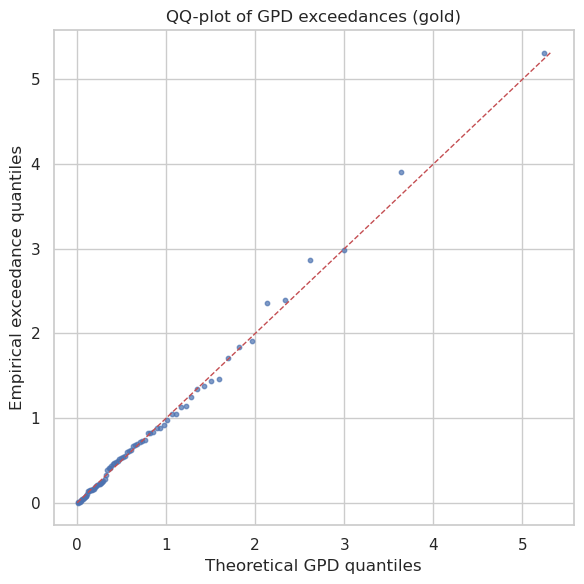

In [98]:
asset = "gold"
res = garch_results[asset]
pars = evt_fits[asset]

z = pd.Series(res.std_resid).dropna().to_numpy()
y = -z
u = pars["threshold_u"]
excesses = np.sort(y[y > u] - u)

p = (np.arange(1, len(excesses) + 1) - 0.5) / len(excesses)
emp_q = excesses
th_q = genpareto.ppf(p, c=pars["xi"], loc=0, scale=pars["beta"])

plt.figure(figsize=(6, 6))
plt.scatter(th_q, emp_q, s=10, alpha=0.7)
lim = max(np.nanmax(th_q), np.nanmax(emp_q))
plt.plot([0, lim], [0, lim], "r--", lw=1)
plt.xlabel("Theoretical GPD quantiles")
plt.ylabel("Empirical exceedance quantiles")
plt.title(f"QQ-plot of GPD exceedances ({asset})")
plt.tight_layout()
plt.show()

## EVT Conclusion

The EVT analysis confirms that tail risk is materially different across assets after GARCH standardization.

- **Physical gold** exhibits the heaviest left tail, indicating potentially severe extreme losses. This is consistent with the largest conditional risk measures in the sample.
- **PAXG** shows a milder tail profile, with lower extreme-loss estimates than physical gold.
- **USD index** has the least severe tail behavior , and the smallest extreme-risk metrics.

Across all assets, ES is consistently more negative than VaR, which is expected and supports internal consistency of the EVT layer.

## Last steps before copula estimation:

1. Build aligned standardized residuals from fitted GARCH models.
2. Build semi-parametric marginal CDFs with EVT tails and empirical center.
3. Transform residuals to pseudo-observations $u_{i,t}\in(0,1)$ (PIT).

In [99]:
# 1) Aligned standardized residuals
z_series = {
    asset: pd.Series(res.std_resid).dropna().rename(asset)
    for asset, res in garch_results.items()
}
z_df = pd.concat(z_series.values(), axis=1, join="inner").dropna()

print(f"Aligned sample size for copula stage: {len(z_df)}")
display(z_df.head())

Aligned sample size for copula stage: 1507


,gold,paxg,usd
0,2.292544,1.673847,-0.513531
1,2.118183,1.108009,-1.196077
2,-0.570864,-0.570857,-1.102696
3,0.363226,1.460192,-2.633570
4,-0.603397,-1.061579,-1.547874


In [100]:
# 2) Semi-parametric EVT marginals (two-sided tails)
def fit_evt_two_sided(z, tail_q=0.95):
    z = np.asarray(z, dtype=float)
    z_low = np.quantile(z, 1 - tail_q)
    z_high = np.quantile(z, tail_q)

    # Left tail via Y_L = -Z
    y_l = -z
    u_l = np.quantile(y_l, tail_q)
    exc_l = y_l[y_l > u_l] - u_l
    xi_l, _, beta_l = genpareto.fit(exc_l, floc=0)
    p_l = len(exc_l) / len(z)

    # Right tail via Y_U = Z
    y_u = z
    u_u = np.quantile(y_u, tail_q)
    exc_u = y_u[y_u > u_u] - u_u
    xi_u, _, beta_u = genpareto.fit(exc_u, floc=0)
    p_u = len(exc_u) / len(z)

    return {
        "z_low": float(z_low),
        "z_high": float(z_high),
        "left": {"u": float(u_l), "xi": float(xi_l), "beta": float(beta_l), "p": float(p_l)},
        "right": {"u": float(u_u), "xi": float(xi_u), "beta": float(beta_u), "p": float(p_u)},
        "z_sorted": np.sort(z),
    }

def empirical_cdf(z_sorted, x):
    # Mid-rank empirical CDF in [1/(2n), 1-1/(2n)]
    n = len(z_sorted)
    r = np.searchsorted(z_sorted, x, side="right")
    return (r - 0.5) / n

def gpd_survival(y, u, xi, beta):
    if y <= u:
        return 1.0
    t = 1.0 + xi * (y - u) / beta
    if t <= 0:
        return 0.0
    if abs(xi) < 1e-8:
        return np.exp(-(y - u) / beta)
    return t ** (-1.0 / xi)

def semiparametric_cdf(z_val, pars):
    z_low = pars["z_low"]
    z_high = pars["z_high"]
    left = pars["left"]
    right = pars["right"]

    if z_val <= z_low:
        y = -z_val
        # F_Z(z) = P(Z<=z) = P(Y_L>=y) ~ p_l * S_GPD(y-u_l)
        f = left["p"] * gpd_survival(y, left["u"], left["xi"], left["beta"])
    elif z_val >= z_high:
        y = z_val
        # 1 - F_Z(z) = P(Z>z) ~ p_u * S_GPD(y-u_u)
        f = 1.0 - right["p"] * gpd_survival(y, right["u"], right["xi"], right["beta"])
    else:
        f = empirical_cdf(pars["z_sorted"], z_val)

    return float(np.clip(f, 1e-6, 1 - 1e-6))

evt_marginals = {asset: fit_evt_two_sided(z_df[asset].to_numpy(), tail_q=0.95) for asset in z_df.columns}
print("Marginals fitted for:", list(evt_marginals.keys()))

Marginals fitted for: ['gold', 'paxg', 'usd']


In [ ]:
# 3) PIT transform: residuals -> pseudo-observations in (0,1)
u_df = pd.DataFrame({
    asset: [semiparametric_cdf(v, evt_marginals[asset]) for v in z_df[asset].to_numpy()]
    for asset in z_df.columns
}, index=z_df.index)

pre_copula_package = {
    "z_df": z_df,
    "u_df": u_df,
    "evt_marginals": evt_marginals,
}

display(u_df.head())
print("- z_df shape:", z_df.shape)
print("- u_df shape:", u_df.shape)

,gold,paxg,usd
0,0.990306,0.951179,0.285003
1,0.985142,0.888852,0.111148
2,0.218646,0.236563,0.135036
3,0.640013,0.929330,0.007732
4,0.206038,0.106503,0.058062


Pre-copula modeling objects ready:
- z_df shape: (1507, 3)
- u_df shape: (1507, 3)
